In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

sys.path.insert(0, str(Path.cwd().resolve() / "src"))

In [13]:
from src.social_memory.transforms.video import load_chunks, sample_frames


import matplotlib.pyplot as plt
import numpy as np
import math


def visualize_frames(frames, title=None, figsize=None, show_indices=True):
    """
    Plot sampled frames in a grid.

    Args:
        frames: list of HWC uint8 arrays (output of sample_frames), or a stacked
                ndarray of shape (N, H, W, C).
        title: optional figure title (e.g. video name or chunk path).
        figsize: optional (width, height) in inches. Auto-sized if None.
        show_indices: if True, label each subplot with its frame index.
    """
    if isinstance(frames, np.ndarray) and frames.ndim == 4:
        frames = list(frames)

    n = len(frames)
    if n == 0:
        print("No frames to visualize")
        return

    # Pick grid dims: 4x4 for n=16, otherwise as-square-as-possible
    if n == 16:
        rows, cols = 4, 4
    else:
        cols = math.ceil(math.sqrt(n))
        rows = math.ceil(n / cols)

    if figsize is None:
        figsize = (cols * 2.5, rows * 2.5)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(frames[i])
            if show_indices:
                ax.set_title(f"frame {i}", fontsize=9)
        ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    else:
        fig.tight_layout()

    plt.show()
    # return fig


In [14]:
import torch
from social_memory.adapters.xclipadapter import XCLIPAdapter

device = torch.device("mps")
encoder = XCLIPAdapter(hidden_dim=512, output_dim=256).to(device)

Loading weights: 100%|██████████| 591/591 [00:00<00:00, 2081.68it/s, Materializing param=visual_projection.weight]                                   
XCLIPModel LOAD REPORT from: microsoft/xclip-base-patch16-16-frames
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
import torch

# Only train the adapter params
trainable = [p for p in encoder.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable, lr=1e-4)

total = sum(p.numel() for p in encoder.parameters())
n_train = sum(p.numel() for p in trainable)
print(f"trainable: {n_train:,} / {total:,} ({100*n_train/total:.2f}%)")


trainable: 787,968 / 195,721,217 (0.40%)


In [ ]:
from src.social_memory.train import SIQ2LongDataset, collate_fn

dataset = SIQ2LongDataset(
    split='val',
    group_by_video=True,
    num_frames_per_video=16,
    max_chunks_per_video=24,
)

Dropping 0 videos with corrupt / too many chunks


In [19]:
len(dataset)

416

loading from GCS...
[worker 4054] -99aZZhUgRk: 5 chunks, 2.95s


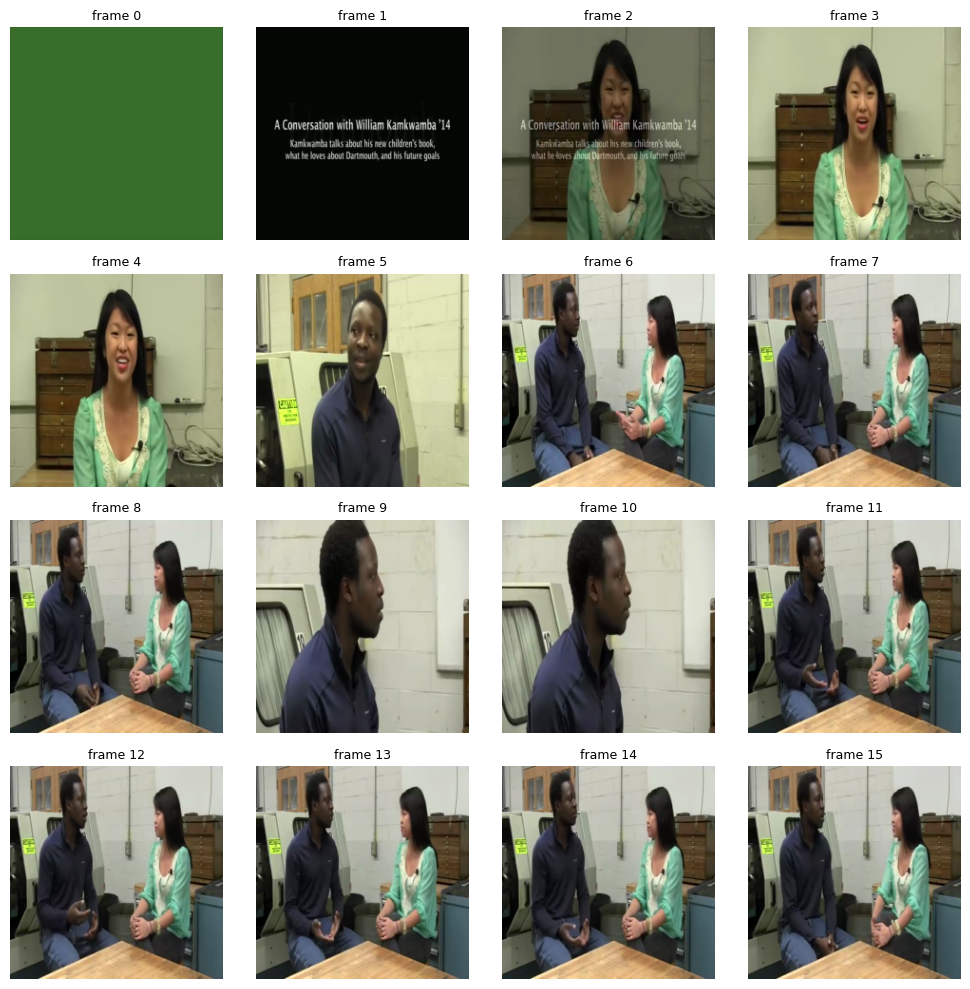

In [20]:
visualize_frames(dataset[0]['chunks'][0]['frames'])

In [22]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    pin_memory=False,
    num_workers=4,          # start here, tune based on CPU count
    # prefetch_factor=4,      # each worker preloads 4 batches
    persistent_workers=False, # avoid re-spawning workers every epoch
    timeout=120,
)

In [23]:
from src.social_memory.train import train

train(
    model=encoder,
    dataloader=dataloader,
    optimizer=optimizer,
    num_epochs=1,
)


=== Epoch 1/1 ===
loading from GCS...
loading from GCS...
loading from GCS...
loading from GCS...


mmco: unref short failure


[worker 23914] -99aZZhUgRk: 5 chunks, 7.66s
loading from GCS...
[worker 23920] 1YFLBjR-swo: 6 chunks, 16.24s
loading from GCS...
[worker 23914] -9NhaKWMtWU: 7 chunks, 13.18s
loading from GCS...
Skipping idx=2: IndexError: tuple index out of range
loading from GCS...


mmco: unref short failure
mmco: unref short failure


[worker 23917] 0LDAgvbRtk4: 11 chunks, 34.94s
loading from GCS...
[worker 23914] -bSM6iswghE: 6 chunks, 19.72s
loading from GCS...
[worker 23920] 1YOzwKKbuPo: 11 chunks, 31.47s
loading from GCS...
[worker 23917] 0SuGC2ifkIA: 10 chunks, 14.76s
loading from GCS...


KeyboardInterrupt: 